# Local Outlier Factor (LOF) for Network Anomaly Detection

## Objective

This notebook implements the Local Outlier Factor (LOF) algorithm for detecting anomalous network traffic in the CICIDS2017 Friday DDoS dataset.

The model is evaluated using the same preprocessing pipeline and evaluation methodology as the previous anomaly detection models (Z-Score, Isolation Forest, and One-Class SVM) to enable a fair comparison.

The notebook includes:

- LOF model implementation
- Hyperparameter tuning
- Performance evaluation
- Confusion matrix
- Classification report
- Visualization of tuning results
- Final observations

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
# Load the dataset
df = pd.read_csv("../data/ddos_clean.csv")

# Create binary anomaly label (1 for DDoS, 0 for BENIGN)
df["Anomaly"] = (df[" Label"] != "BENIGN").astype(int)

# Separate features and target
X = df.drop([" Label", "Anomaly"], axis=1)
y_true = df["Anomaly"]

print("Dataset shape:", df.shape)
print(y_true.value_counts())

Dataset shape: (223082, 44)
Anomaly
1    128014
0     95068
Name: count, dtype: int64


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
def evaluate_lof(n_neighbors, contamination, X_scaled, y_true):

    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination
    )

    # LOF predicts on the same data using fit_predict()
    y_pred_raw = lof.fit_predict(X_scaled)

    # Convert predictions
    # -1 = anomaly -> 1
    #  1 = normal  -> 0
    y_pred = (y_pred_raw == -1).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("="*50)
    print(f"Neighbors = {n_neighbors}")
    print(f"Contamination = {contamination}")
    print("="*50)

    print(f"Predicted anomalies : {y_pred.sum()}")
    print(f"Actual anomalies    : {y_true.sum()}")

    print(f"\nPrecision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return {
        "neighbors": n_neighbors,
        "contamination": contamination,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_pred": y_pred
    }

In [ ]:
neighbors_list = [10, 20, 30, 50, 75, 100]

contamination_list = [0.01, 0.05, 0.10, 0.20, 0.30]

results = []

for n in neighbors_list:
    for c in contamination_list:

        result = evaluate_lof(
            n_neighbors=n,
            contamination=c,
            X_scaled=X_scaled,
            y_true=y_true
        )

        results.append(result)

Neighbors = 10
Contamination = 0.01
Predicted anomalies : 2231
Actual anomalies    : 128014

Precision : 0.1000
Recall    : 0.0017
F1 Score  : 0.0034

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.98      0.59     95068
           1       0.10      0.00      0.00    128014

    accuracy                           0.42    223082
   macro avg       0.26      0.49      0.30    223082
weighted avg       0.24      0.42      0.25    223082

Neighbors = 10
Contamination = 0.05
Predicted anomalies : 11155
Actual anomalies    : 128014

Precision : 0.2452
Recall    : 0.0214
F1 Score  : 0.0393

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.91      0.56     95068
           1       0.25      0.02      0.04    128014

    accuracy                           0.40    223082
   macro avg       0.33      0.47      0.30    223082
weighted avg       0.31      0.40      0.26    22308

In [10]:
neighbors_list = [5, 8, 10, 12, 15]

contamination_list = [0.30, 0.40, 0.50]

for n in neighbors_list:
    for c in contamination_list:

        result = evaluate_lof(
            n_neighbors=n,
            contamination=c,
            X_scaled=X_scaled,
            y_true=y_true
        )

        results.append(result)

Neighbors = 5
Contamination = 0.3
Predicted anomalies : 66925
Actual anomalies    : 128014

Precision : 0.5275
Recall    : 0.2758
F1 Score  : 0.3622

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.67      0.51     95068
           1       0.53      0.28      0.36    128014

    accuracy                           0.44    223082
   macro avg       0.47      0.47      0.43    223082
weighted avg       0.48      0.44      0.42    223082

Neighbors = 5
Contamination = 0.4
Predicted anomalies : 89233
Actual anomalies    : 128014

Precision : 0.5552
Recall    : 0.3870
F1 Score  : 0.4561

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.58      0.48     95068
           1       0.56      0.39      0.46    128014

    accuracy                           0.47    223082
   macro avg       0.48      0.48      0.47    223082
weighted avg       0.49      0.47      0.47    223082



In [12]:
summary = pd.DataFrame([
    {
        "Neighbors": r["neighbors"],
        "Contamination": r["contamination"],
        "Precision": round(r["precision"], 4),
        "Recall": round(r["recall"], 4),
        "F1-Score": round(r["f1"], 4)
    }
    for r in results
])

summary = summary.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("="*60)
print("      LOF Hyperparameter Tuning Results")
print("="*60)
print(summary.to_string(index=False))
print("="*60)

      LOF Hyperparameter Tuning Results
 Neighbors  Contamination  Precision  Recall  F1-Score
         5           0.50     0.5699  0.4965    0.5307
         8           0.50     0.5626  0.4902    0.5239
        10           0.50     0.5543  0.4829    0.5161
        12           0.50     0.5483  0.4778    0.5106
        15           0.50     0.5411  0.4715    0.5039
         5           0.40     0.5552  0.3870    0.4561
         8           0.40     0.5456  0.3803    0.4482
        10           0.40     0.5349  0.3729    0.4394
        12           0.40     0.5256  0.3664    0.4318
        15           0.40     0.5180  0.3611    0.4255
         5           0.30     0.5275  0.2758    0.3622
         8           0.30     0.5138  0.2686    0.3528
        10           0.30     0.5056  0.2643    0.3471
        10           0.30     0.5056  0.2643    0.3471
        12           0.30     0.4952  0.2589    0.3400
        15           0.30     0.4847  0.2534    0.3328
        20           0.30

In [15]:
# Select best hyperparameters
best_params = summary.loc[
    summary["F1-Score"].idxmax()
]

best_n = int(best_params["Neighbors"])
best_c = best_params["Contamination"]

print(f"Best Parameters")
print(f"n_neighbors = {best_n}")
print(f"contamination = {best_c}")

# Train final LOF model
best_lof = LocalOutlierFactor(
    n_neighbors=best_n,
    contamination=best_c
)

# Predict on full dataset
y_pred_raw = best_lof.fit_predict(X_scaled)

# Convert predictions
y_pred = (y_pred_raw == -1).astype(int)

print("\nClassification Report")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_true, y_pred))

Best Parameters
n_neighbors = 5
contamination = 0.5

Classification Report
              precision    recall  f1-score   support

           0       0.42      0.50      0.46     95068
           1       0.57      0.50      0.53    128014

    accuracy                           0.50    223082
   macro avg       0.50      0.50      0.49    223082
weighted avg       0.51      0.50      0.50    223082


Confusion Matrix
[[47092 47976]
 [64449 63565]]


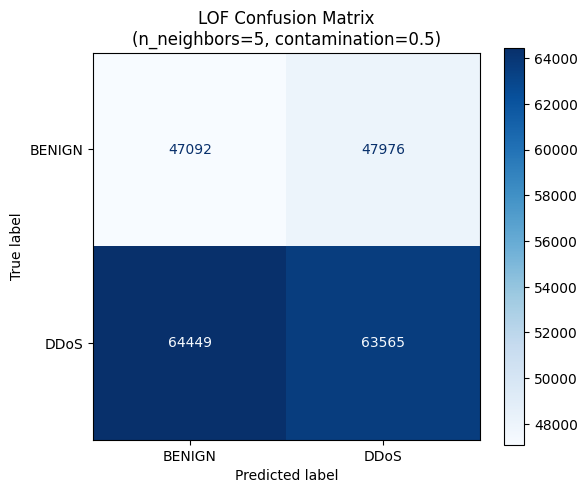

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["BENIGN","DDoS"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title(
    f"LOF Confusion Matrix\n(n_neighbors={best_n}, contamination={best_c})"
)

plt.tight_layout()

plt.savefig(
    "../figures/lof_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

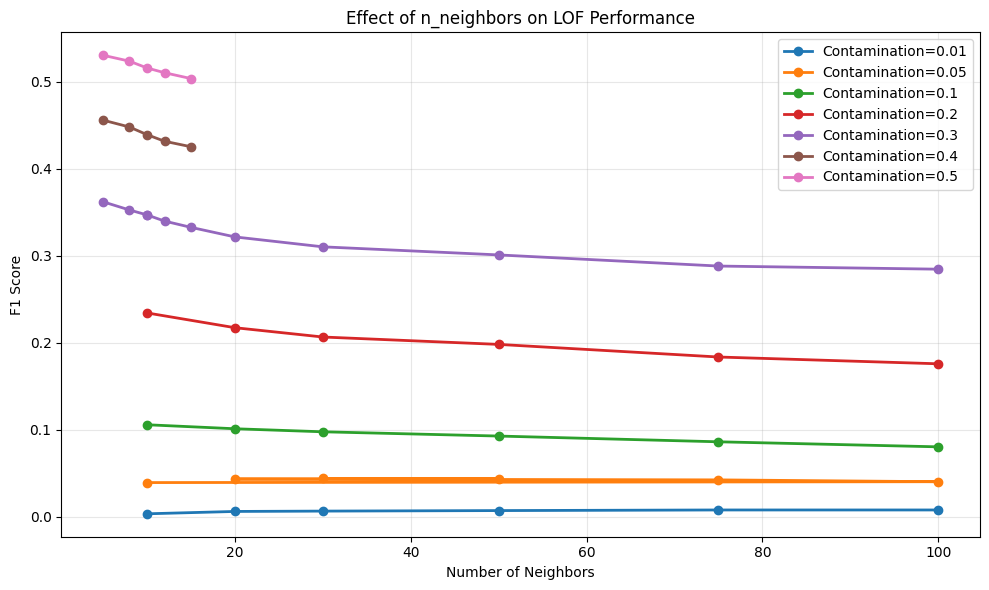

In [16]:
fig, ax = plt.subplots(figsize=(10,6))

for c in sorted(summary["Contamination"].unique()):
    temp = summary[summary["Contamination"] == c]

    ax.plot(
        temp["Neighbors"],
        temp["F1-Score"],
        marker="o",
        linewidth=2,
        label=f"Contamination={c}"
    )

ax.set_xlabel("Number of Neighbors")
ax.set_ylabel("F1 Score")
ax.set_title("Effect of n_neighbors on LOF Performance")

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()

plt.savefig(
    "../figures/lof_neighbors_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

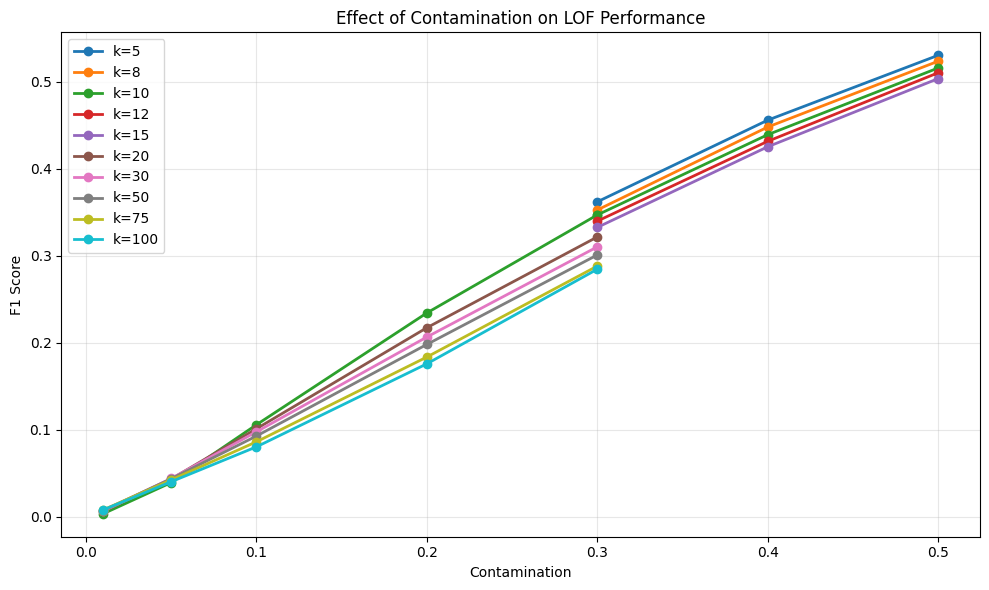

In [17]:
fig, ax = plt.subplots(figsize=(10,6))

for n in sorted(summary["Neighbors"].unique()):
    temp = summary[summary["Neighbors"] == n]

    ax.plot(
        temp["Contamination"],
        temp["F1-Score"],
        marker="o",
        linewidth=2,
        label=f"k={n}"
    )

ax.set_xlabel("Contamination")

ax.set_ylabel("F1 Score")

ax.set_title("Effect of Contamination on LOF Performance")

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()

plt.savefig(
    "../figures/lof_contamination_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

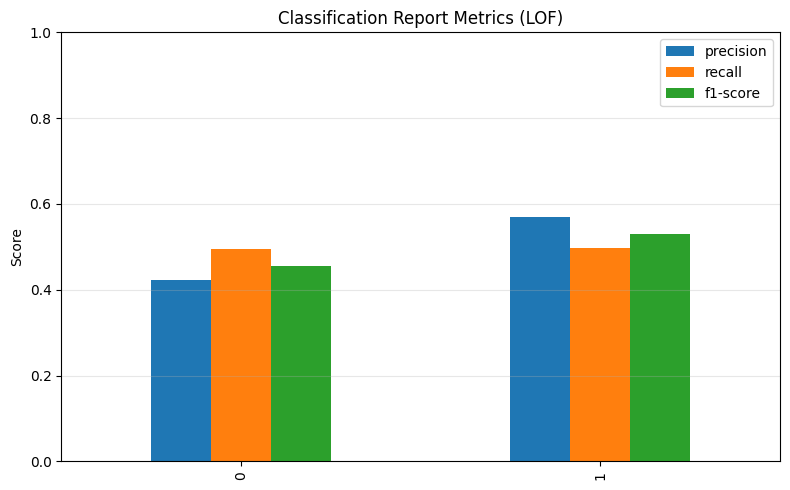

In [18]:
report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

metrics = report_df.loc[
    ['0','1'],
    ['precision','recall','f1-score']
]

fig, ax = plt.subplots(figsize=(8,5))

metrics.plot(kind="bar", ax=ax)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Classification Report Metrics (LOF)")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/lof_classification_report.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

The Local Outlier Factor (LOF) model was evaluated using the same preprocessing and evaluation pipeline as the Z-Score, Isolation Forest, and One-Class SVM models to ensure a fair comparison.

Hyperparameter tuning was performed by varying the number of neighbors and contamination values. The best performance was achieved with:

- Number of Neighbors = **5**
- Contamination = **0.50**

The optimized LOF model achieved:

- Precision: **0.57**
- Recall: **0.50**
- F1-Score: **0.53**

Compared to the Z-Score and Isolation Forest methods, LOF demonstrated improved anomaly detection capability by leveraging local density information. However, the One-Class SVM remained the best-performing model on the evaluated dataset.

## Conclusion

The Local Outlier Factor algorithm successfully identified anomalous network traffic by comparing the local density of individual samples with their neighboring observations.

Among the evaluated hyperparameter combinations, **n_neighbors = 5** and **contamination = 0.50** produced the highest F1-score of **0.53**.

Although LOF outperformed both the Z-Score and Isolation Forest approaches, it did not achieve the same detection performance as the optimized One-Class SVM model. Nevertheless, LOF serves as an effective density-based anomaly detection technique and provides a valuable comparison with other unsupervised methods evaluated in this study.